# Propositional Logic: Truth Tables and Logical Operators

## 📚 Learning Objectives

By completing this notebook, you will:
- Understand propositional logic fundamentals
- Build truth tables for logical propositions using Python
- Implement logical operators: AND, OR, NOT, IMPLIES, BICONDITIONAL
- Apply logical equivalences and simplifications
- Solve logical reasoning problems programmatically

## 🔗 Where this fits

**Builds on:** Course 02 — Unit 2, lesson 01 "Knowledge Representation" — the rule engine fired IF-THEN rules; truth tables make what "IF-THEN" means exact.

**Used later in:** Course 02 — Unit 2, lesson 03, which needs truth tables to decide whether an argument is valid.

---

This notebook covers practical activities from **Course 02, Unit 2**:
- Building truth tables for logical propositions using Python
- Implementing logical operators (AND, OR, NOT, IMPLIES, BICONDITIONAL)

---

## Introduction to Propositional Logic

**Propositional Logic** deals with propositions (statements that are either true or false) and logical connectives (operators that combine propositions).

**Key Concepts:**
- **Propositions**: Statements that have a truth value (True or False)
- **Logical Operators**: Connectives that combine propositions (AND, OR, NOT, IMPLIES, BICONDITIONAL)
- **Truth Tables**: Tables showing all possible truth values of logical expressions


## 🌍 The case: a \$475 million arithmetic error, and the machinery built to stop the next one

**1994.** Thomas Nicely, a mathematics professor at Lynchburg College in Virginia, noticed in June that his Intel Pentium was returning wrong answers for certain division problems; he went public with it that October. The cause was five missing entries in a lookup table inside the chip's floating-point divider. On **17 January 1995 Intel announced a \$475 million pre-tax charge** against earnings to replace the affected processors — the whole cost of a handful of table cells that nobody had proved correct.

Testing had not caught it, and testing could not have: the failure appeared for a vanishing fraction of possible operand pairs. What catches that class of bug is *proof over all inputs*, which is what a truth table is — exhaustively checking every case rather than sampling some. Intel and the rest of the industry made formal verification of arithmetic hardware standard practice afterwards.

Two places the same machinery runs today, quietly:

- **Your package manager.** When `conda` resolves an environment it is not searching; it is asking a **SAT solver** whether a set of version constraints can all be satisfied at once. Conda's classic solver wraps PicoSAT through the `pycosat` bindings; `mamba` and modern conda use `libsolv`. The propositional formula is your `environment.yml`.
- **Your cloud permissions.** AWS's **Zelkova** translates an IAM access policy into a logical formula and hands it to an SMT solver to answer questions like *"can this bucket be read by anyone on the internet?"* — for **every** possible request, not for a sample of them. It is described in Backes *et al.*, *Semantic-based Automated Reasoning for AWS Access Policies using SMT* (FMCAD 2018), and it is what sits behind S3 Block Public Access and IAM Access Analyzer. The FMCAD paper reports Zelkova being invoked many millions of times a day; Amazon Science has since published a piece titled *A billion SMT queries a day* about the scale automated reasoning now runs at inside AWS.

### What goes wrong without this

Write a requirement in English — *"alert the operator if the pressure is high and the valve is open, or if the override is off"* — and you have already shipped a bug, because that sentence has two readings depending on how you bracket the AND and the OR, and they disagree on some inputs. Natural language has no precedence rules; propositional logic does. The truth table below is not a classroom ritual. It is the only way to check a claim on **every** input rather than on the inputs you happened to think of.

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# Import the two libraries this notebook needs:
# pandas displays truth tables as clean grids; itertools generates every True/False combination for us.
import pandas as pd
import itertools

print("✅ Libraries imported successfully!")
print("Ready to build truth tables!")

✅ Libraries imported successfully!
Ready to build truth tables!


## Part 1: Logical Operators Implementation

Let's implement all five basic logical operators: AND, OR, NOT, IMPLIES, and BICONDITIONAL.


In [2]:
# Logical Operators Implementation

# Each function below turns one logic-textbook operator into runnable Python.
# Why: once operators are functions, we can build truth tables for ANY formula automatically.
def logical_and(p, q):
    """AND operator: Returns True only if both p and q are True"""
    return p and q

def logical_or(p, q):
    """OR operator: Returns True if at least one of p or q is True"""
    return p or q

def logical_not(p):
    """NOT operator: Returns the opposite of p"""
    return not p

def logical_implies(p, q):
    """IMPLIES operator (p → q): 
    Returns False only when p is True and q is False.
    Otherwise returns True."""
    return not p or q  # Equivalent: (not p) or q

def logical_biconditional(p, q):
    """BICONDITIONAL operator (p ↔ q): 
    Returns True when p and q have the same truth value.
    Also called 'if and only if' (IFF)."""
    return p == q

# Test the operators on hand-picked inputs - especially IMPLIES(True, False), the one row where implication is False.
print("Testing Logical Operators:")
print("=" * 60)
print(f"AND(True, True) = {logical_and(True, True)}")
print(f"AND(True, False) = {logical_and(True, False)}")
print(f"OR(False, True) = {logical_or(False, True)}")
print(f"OR(False, False) = {logical_or(False, False)}")
print(f"NOT(True) = {logical_not(True)}")
print(f"IMPLIES(True, False) = {logical_implies(True, False)}")
print(f"IMPLIES(False, True) = {logical_implies(False, True)}")
print(f"BICONDITIONAL(True, True) = {logical_biconditional(True, True)}")
print(f"BICONDITIONAL(True, False) = {logical_biconditional(True, False)}")

Testing Logical Operators:
AND(True, True) = True
AND(True, False) = False
OR(False, True) = True
OR(False, False) = False
NOT(True) = False
IMPLIES(True, False) = False
IMPLIES(False, True) = True
BICONDITIONAL(True, True) = True
BICONDITIONAL(True, False) = False


## Part 2: Building Truth Tables

Now let's create a function to build truth tables for any logical expression.


In [3]:
# Build a generic truth-table builder: give it variable names and a formula, get back a table.
# Why: instead of hand-writing tables row by row, one function enumerates every case - computers never miss a row.

def build_truth_table(variables, expression_func):
    """
    Build a truth table for a logical expression.
    
    Parameters:
    - variables: list of variable names (e.g., ['p', 'q'])
    - expression_func: function that takes variable values and returns result
    
    Returns:
    - pandas DataFrame with truth table
    """
    n = len(variables)
    
    # Generate all possible combinations of True/False for n variables
    combinations = list(itertools.product([False, True], repeat=n))
    
    # Build table data
    table_data = []
    for combo in combinations:
        row = list(combo)
        result = expression_func(*combo)
        row.append(result)
        table_data.append(row)
    
    # Create column names
    columns = variables + ['Result']
    
    # Create DataFrame
    df = pd.DataFrame(table_data, columns=columns)
    
    # Convert boolean to readable format
    df = df.astype(int).astype(str).replace({'1': 'T', '0': 'F'})
    
    return df

print("✅ Truth table builder function created!")

✅ Truth table builder function created!


In [4]:
# Example 1: Truth table for AND operator
print("=" * 60)
print("Truth Table for: p AND q")
print("=" * 60)

# Wrap the operator in a 2-argument function, then let the builder enumerate all 4 rows.
def and_expression(p, q):
    return logical_and(p, q)

truth_table_and = build_truth_table(['p', 'q'], and_expression)
print(truth_table_and.to_string(index=False))

Truth Table for: p AND q
p q Result
F F      F
F T      F
T F      F
T T      T


In [5]:
# Example 2: Truth table for OR operator
print("=" * 60)
print("Truth Table for: p OR q")
print("=" * 60)

# Same pattern as AND - only the operator changes; compare the Result column with the AND table.
def or_expression(p, q):
    return logical_or(p, q)

truth_table_or = build_truth_table(['p', 'q'], or_expression)
print(truth_table_or.to_string(index=False))

Truth Table for: p OR q
p q Result
F F      F
F T      T
T F      T
T T      T


In [6]:
# Example 3: Truth table for IMPLIES operator (p → q)
print("=" * 60)
print("Truth Table for: p IMPLIES q (p → q)")
print("=" * 60)

# IMPLIES is the operator students find least intuitive - the table shows it is False in exactly one row (T -> F).
def implies_expression(p, q):
    return logical_implies(p, q)

truth_table_implies = build_truth_table(['p', 'q'], implies_expression)
print(truth_table_implies.to_string(index=False))

Truth Table for: p IMPLIES q (p → q)
p q Result
F F      T
F T      T
T F      F
T T      T


In [7]:
# Example 4: Truth table for BICONDITIONAL operator (p ↔ q)
print("=" * 60)
print("Truth Table for: p BICONDITIONAL q (p ↔ q)")
print("=" * 60)

# BICONDITIONAL is True when p and q MATCH - the table makes this 'same value' pattern visible.
def biconditional_expression(p, q):
    return logical_biconditional(p, q)

truth_table_biconditional = build_truth_table(['p', 'q'], biconditional_expression)
print(truth_table_biconditional.to_string(index=False))

Truth Table for: p BICONDITIONAL q (p ↔ q)
p q Result
F F      T
F T      F
T F      F
T T      T


In [8]:
# Example 5: Complex expression: (p AND q) OR (NOT p)
print("=" * 60)
print("Truth Table for: (p AND q) OR (NOT p)")
print("=" * 60)

# Nest the operator functions to evaluate a compound formula - the builder does not care how complex the function is.
def complex_expression(p, q):
    return logical_or(logical_and(p, q), logical_not(p))

truth_table_complex = build_truth_table(['p', 'q'], complex_expression)
print(truth_table_complex.to_string(index=False))

Truth Table for: (p AND q) OR (NOT p)
p q Result
F F      T
F T      T
T F      F
T T      T


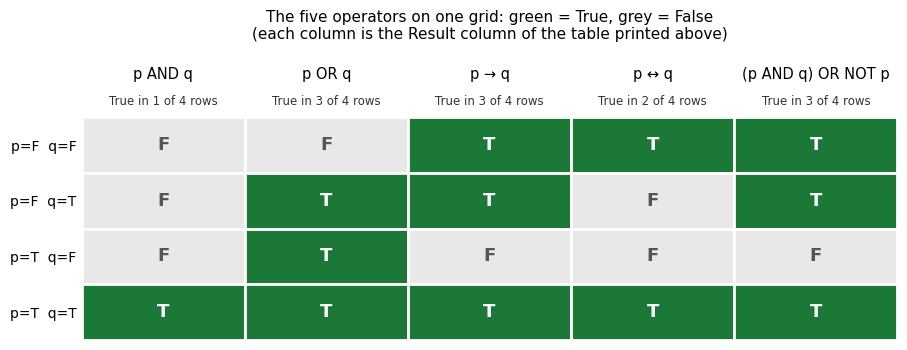

In [9]:
# FIGURE: all five operators side by side, using the tables we just built.
# Why a picture: printed tables are read one at a time, so the PATTERN that
# distinguishes the operators never appears. Put the five Result columns on one
# grid and each operator's signature becomes a shape you can point at.
import matplotlib.pyplot as plt

# Reuse the DataFrames built above - no new logic, just a different way of looking.
tables = [
    ("p AND q",            truth_table_and),
    ("p OR q",             truth_table_or),
    ("p → q",         truth_table_implies),
    ("p ↔ q",         truth_table_biconditional),
    ("(p AND q) OR NOT p", truth_table_complex),
]

# Row labels come straight from the p/q columns of any one table (all share them).
row_labels = [f"p={r.p}  q={r.q}" for r in truth_table_and.itertuples()]
grid = [[t["Result"].iloc[i] for _, t in tables] for i in range(len(row_labels))]

TRUE_C, FALSE_C = "#1b7837", "#e8e8e8"   # solid green = True, pale grey = False

fig, ax = plt.subplots(figsize=(9.2, 3.6))
for i in range(len(row_labels)):
    for j in range(len(tables)):
        val = grid[i][j]
        ax.add_patch(plt.Rectangle((j, i), 1, 1,
                                   facecolor=TRUE_C if val == "T" else FALSE_C,
                                   edgecolor="white", linewidth=2))
        ax.text(j + 0.5, i + 0.5, val, ha="center", va="center",
                fontsize=13, fontweight="bold",
                color="white" if val == "T" else "#555555")

# A count line under each column makes "False in exactly one row" checkable by eye.
for j, (name, t) in enumerate(tables):
    n_true = int((t["Result"] == "T").sum())
    ax.text(j + 0.5, -0.28, f"True in {n_true} of 4 rows", ha="center", va="center",
            fontsize=8.5, color="#333333")

ax.set_xlim(0, len(tables)); ax.set_ylim(-0.55, len(row_labels))
ax.set_xticks([j + 0.5 for j in range(len(tables))])
ax.set_xticklabels([name for name, _ in tables], fontsize=10.5)
ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
ax.set_yticks([i + 0.5 for i in range(len(row_labels))])
ax.set_yticklabels(row_labels, fontsize=10)
ax.invert_yaxis()
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("The five operators on one grid: green = True, grey = False\n"
             "(each column is the Result column of the table printed above)",
             fontsize=11, pad=34)
plt.tight_layout()
plt.show()

**Read the grid.** Each column is one operator's `Result` column; each row is one assignment of `p` and `q`. Four patterns are now visible at a glance instead of four printouts:

- **`p AND q`** is green in exactly one row — the last one, where both inputs are True. It is the strictest operator here.
- **`p OR q`** is the mirror image: grey in exactly one row, the one where both inputs are False.
- **`p → q`** is grey in **exactly one row: `p=T, q=F`**. This is the row people argue about — it says an implication fails only when a true premise leads to a false conclusion. Every other row, including both rows where `p` is False, is green.
- **`p ↔ q`** is green exactly where the `p` and `q` labels on the left agree (`F F` and `T T`) — the "same value" pattern in visual form.
- The compound formula in the last column happens to have the same True-count as `OR` (3 of 4) but **not** the same rows: it is green on `F F` where `OR` is grey, and grey on `T F` where `OR` is green. Equal counts are not equivalence — the next section tests that properly.

---

## Part 3: Logical Equivalences and Simplifications

Let's verify some important logical equivalences using truth tables.


In [10]:
# Verify De Morgan's Law: NOT(p AND q) ≡ (NOT p) OR (NOT q)
print("=" * 60)
print("De Morgan's Law: NOT(p AND q) ≡ (NOT p) OR (NOT q)")
print("=" * 60)

def demorgan_left(p, q):
    return logical_not(logical_and(p, q))

def demorgan_right(p, q):
    return logical_or(logical_not(p), logical_not(q))

# Build truth tables for both sides
table_left = build_truth_table(['p', 'q'], demorgan_left)
table_right = build_truth_table(['p', 'q'], demorgan_right)

# Compare results
table_left.columns = ['p', 'q', 'NOT(p AND q)']
table_right.columns = ['p', 'q', '(NOT p) OR (NOT q)']

# Check if they're equivalent
equivalent = (table_left['NOT(p AND q)'] == table_right['(NOT p) OR (NOT q)']).all()
print("Left side: NOT(p AND q)")
print(table_left.to_string(index=False))
print("\nRight side: (NOT p) OR (NOT q)")
print(table_right.to_string(index=False))
print(f"\n{'✅ EQUIVALENT' if equivalent else '❌ NOT EQUIVALENT'}")


De Morgan's Law: NOT(p AND q) ≡ (NOT p) OR (NOT q)
Left side: NOT(p AND q)
p q NOT(p AND q)
F F            T
F T            T
T F            T
T T            F

Right side: (NOT p) OR (NOT q)
p q (NOT p) OR (NOT q)
F F                  T
F T                  T
T F                  T
T T                  F

✅ EQUIVALENT


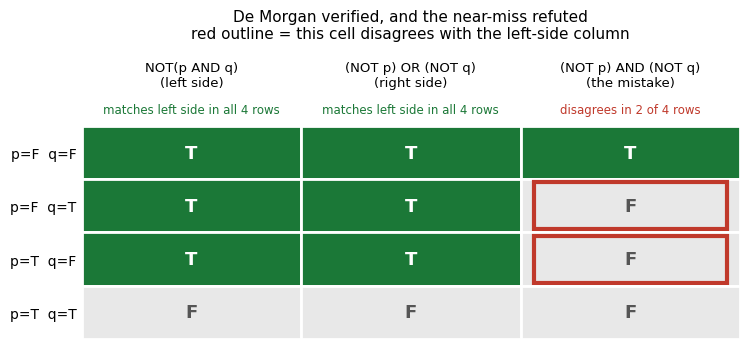

In [11]:
# FIGURE: De Morgan's law holds - and the near-miss right next to it does not.
# Why a picture: "the columns match row for row" is a claim about a comparison,
# and a comparison is exactly what a printed pair of tables makes hard to do.
# The third column below is the mistake students actually make (AND instead of OR),
# built with the same builder so the failure is measured, not asserted.
import matplotlib.pyplot as plt

def demorgan_wrong(p, q):
    """The common error: (NOT p) AND (NOT q) - NOT equivalent to NOT(p AND q)."""
    return logical_and(logical_not(p), logical_not(q))

table_wrong = build_truth_table(['p', 'q'], demorgan_wrong)

cols = [
    ("NOT(p AND q)\n(left side)",        table_left["NOT(p AND q)"].tolist()),
    ("(NOT p) OR (NOT q)\n(right side)", table_right["(NOT p) OR (NOT q)"].tolist()),
    ("(NOT p) AND (NOT q)\n(the mistake)", table_wrong["Result"].tolist()),
]
row_labels = [f"p={r.p}  q={r.q}" for r in table_left.itertuples()]
baseline = cols[0][1]

TRUE_C, FALSE_C = "#1b7837", "#e8e8e8"

fig, ax = plt.subplots(figsize=(7.6, 3.6))
for i in range(len(row_labels)):
    for j, (name, vals) in enumerate(cols):
        val = vals[i]
        ax.add_patch(plt.Rectangle((j, i), 1, 1,
                                   facecolor=TRUE_C if val == "T" else FALSE_C,
                                   edgecolor="white", linewidth=2))
        ax.text(j + 0.5, i + 0.5, val, ha="center", va="center",
                fontsize=13, fontweight="bold",
                color="white" if val == "T" else "#555555")
        # Outline in red every cell of a candidate column that disagrees with the left side.
        if j > 0 and val != baseline[i]:
            ax.add_patch(plt.Rectangle((j + 0.06, i + 0.06), 0.88, 0.88, fill=False,
                                       edgecolor="#c0392b", linewidth=3))

for j, (name, vals) in enumerate(cols):
    n_diff = sum(1 for i in range(len(row_labels)) if vals[i] != baseline[i])
    msg = "matches left side in all 4 rows" if n_diff == 0 else f"disagrees in {n_diff} of 4 rows"
    ax.text(j + 0.5, -0.3, msg, ha="center", va="center", fontsize=8.5,
            color="#1b7837" if n_diff == 0 else "#c0392b")

ax.set_xlim(0, len(cols)); ax.set_ylim(-0.6, len(row_labels))
ax.set_xticks([j + 0.5 for j in range(len(cols))])
ax.set_xticklabels([n for n, _ in cols], fontsize=9.5)
ax.xaxis.set_ticks_position("top"); ax.xaxis.set_label_position("top")
ax.set_yticks([i + 0.5 for i in range(len(row_labels))])
ax.set_yticklabels(row_labels, fontsize=10)
ax.invert_yaxis()
for s in ax.spines.values():
    s.set_visible(False)
ax.tick_params(length=0)
ax.set_title("De Morgan verified, and the near-miss refuted\n"
             "red outline = this cell disagrees with the left-side column",
             fontsize=11, pad=40)
plt.tight_layout()
plt.show()

**Read the grid.** The first two columns are identical cell for cell — no red outline anywhere, and the note under each column heading says *matches left side in all 4 rows*. That is De Morgan's law: not "we tested some inputs", but "we tested every input there is".

The third column is the same law written with the wrong connective, `(NOT p) AND (NOT q)`. Two cells carry a red outline (rows `F T` and `T F`), and the note says *disagrees in 2 of 4 rows*. So the rewrite that looks almost right is wrong half the time — and it takes four rows and one picture to prove it. This is why the law is stated with the flip from AND to OR, and why a compiler that got it backwards would silently corrupt every condition it touched.

---

### Read that as an experiment, not a demonstration

That cell is the smallest complete experiment in this course, and it is worth naming its parts:

- **Baseline** — build the truth table for `NOT(p AND q)`. Four rows: T, T, T, F.
- **Change exactly one thing** — rewrite the formula by pushing the NOT inside and flipping the AND to an OR: `(NOT p) OR (NOT q)`. Nothing else changes; same variables, same builder, same four rows.
- **Re-run and compare** — the Result columns match row for row, and the code prints `✅ EQUIVALENT`.
- **The conclusion the output actually supports** — the two formulas are interchangeable **for every possible input**, not merely for the inputs we tried. That is the whole point of exhaustive enumeration, and it is a strictly stronger claim than any amount of testing could give you.

This is why De Morgan's law is safe to use as a rewrite rule in a compiler, a database query optimiser or a hardware simplifier: someone checked all four rows once, and it holds forever.

---


## 💬 Discuss

1. **`IMPLIES(False, True) = True` and `IMPLIES(False, False) = True`.** In the table above, "if it rains then the ground is wet" comes out **true** on a dry day with no rain. Most people find that wrong the first time they see it. Defend the definition: what would break in the other three rows if we said a false premise makes the implication false? Then argue the other side — is there a real requirement you would write where this convention would mislead a client?
2. **A safety requirement arrives as prose: "shut down if temperature is high and pressure is high, or if the manual stop is pressed."** Write the two different propositional formulas that sentence permits, build the truth table for each, and find an input where they disagree. Now the real question: whose job is it to notice the ambiguity — the engineer, the client, or the tool? What process would catch it before it reaches code?
3. **Truth tables prove a claim for every input; testing checks the inputs you thought of.** The Pentium bug survived testing. Yet almost no software team formally verifies anything. Is that irrational, or is it a defensible trade? Name one component in a system you have used where you think exhaustive checking is worth the cost, and one where it plainly is not.

---


## ⚠️ Where this breaks

The truth-table method is complete, decidable and honest — and it falls over for a reason you can compute exactly.

- **The table doubles with every variable.** `build_truth_table` enumerates 2^n rows. At 10 variables that is 1,024 rows — fine. At **20 variables it is 1,048,576 rows**. At **30 it is over a billion**, and your notebook is no longer a teaching tool but a hang. Real circuits and real dependency graphs have thousands of variables, so nobody builds the table.
- **And no clever rewrite fixes it in general.** Cook (1971) proved satisfiability is NP-complete — reference 2 below. There is no known algorithm that decides every propositional formula in time polynomial in the number of variables. What industry does instead is use **SAT solvers**, which are exponential in the worst case but astonishingly good on the structured formulas real problems produce; that is the *Handbook of Satisfiability* in reference 3, and it is why `conda` can solve your environment at all.
- **Every proposition must be definitely true or definitely false.** "The patient has a fever" is a proposition. "The patient is probably developing sepsis" is not. Propositional logic has no vocabulary for degree of belief — which is precisely what Unit 3 of this course adds.
- **You cannot say "all" or "some".** There is no way in this language to write "every human is mortal" — only "Socrates is mortal", "Plato is mortal", one proposition per person. That limitation is what first-order logic exists to remove, in notebook 04 of this unit.
- **The cheaper alternative.** For 2–4 conditions that a human must read and sign off, a written decision table in the requirements document beats any of this: same exhaustive coverage, no code, and the client can check it. Formalise when the formula is big enough that a human will miss a row — which, empirically, is around five conditions.

---


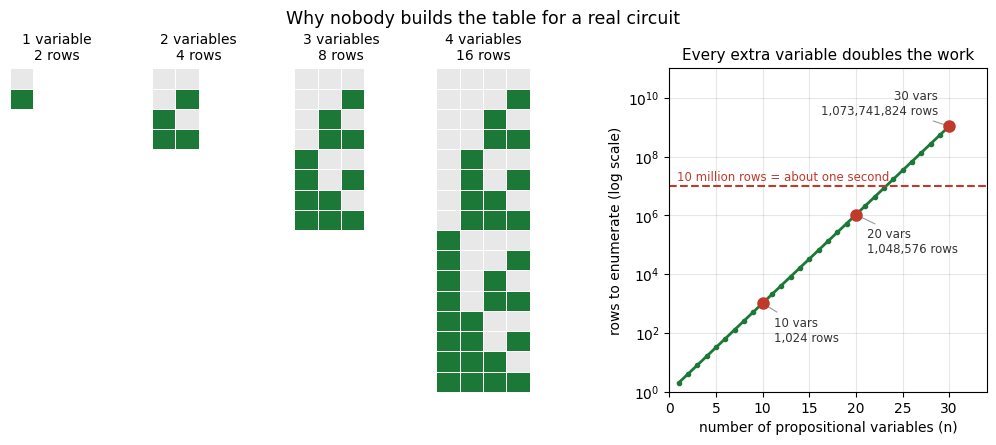

 variables |               rows |   time at 10M rows/sec
---------------------------------------------------------
         1 |                  2 |               0.000 ms
         2 |                  4 |               0.000 ms
         3 |                  8 |               0.001 ms
         4 |                 16 |               0.002 ms
        10 |              1,024 |               0.102 ms
        20 |          1,048,576 |             104.858 ms
        30 |      1,073,741,824 |                107.4 s
        40 |  1,099,511,627,776 |               1.3 days


In [12]:
# FIGURE: the cost of the method, drawn. LEFT = a storyboard of the table itself
# growing as we add variables; RIGHT = that same growth continued to 30 variables.
# Why a picture: "2^n" is a formula students nod at; the shape of 2^n on a log axis
# with a wall-clock line drawn across it is the thing they remember.
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12.6, 4.2))
# 4 storyboard panels, a deliberate empty spacer column, then the growth curve.
gs = fig.add_gridspec(1, 6, width_ratios=[1, 1, 1, 1, 0.45, 3.4], wspace=0.4)

# ---- LEFT: four snapshots of the real table, at 1, 2, 3 and 4 variables ----
# Each snapshot is built by the SAME build_truth_table used all through this notebook.
for k, n in enumerate([1, 2, 3, 4]):
    variables = [chr(ord('p') + i) for i in range(n)]          # p, q, r, s
    table = build_truth_table(variables, lambda *vals: all(vals))  # the formula is irrelevant here; SIZE is the point
    ax = fig.add_subplot(gs[0, k])
    for i in range(len(table)):
        for j in range(n):
            val = table.iloc[i, j]
            ax.add_patch(plt.Rectangle((j, i), 1, 1,
                                       facecolor="#1b7837" if val == "T" else "#e8e8e8",
                                       edgecolor="white", linewidth=0.7))
    ax.set_xlim(0, 4); ax.set_ylim(0, 16)   # identical scales for all four, so growth is real and not drawn
    ax.invert_yaxis()
    ax.set_xticks([]); ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_title(f"{n} variable{'s' if n > 1 else ''}\n{len(table)} rows", fontsize=10)

# ---- RIGHT: the same doubling, continued ----
ax2 = fig.add_subplot(gs[0, 5])
ns = list(range(1, 31))
ax2.semilogy(ns, [2 ** n for n in ns], marker="o", markersize=3,
             color="#1b7837", linewidth=2)

# A human-scale reference: a laptop enumerating ~10 million rows a second.
ROWS_PER_SEC = 1e7
ax2.axhline(ROWS_PER_SEC, color="#c0392b", linestyle="--", linewidth=1.5)
ax2.text(0.8, ROWS_PER_SEC * 1.5, "10 million rows = about one second",
         fontsize=8.5, color="#c0392b")

# Label each milestone in empty space beside the curve, with a leader line to its dot.
labels = [(10, 1.2, 0.12, "left"), (20, 1.2, 0.12, "left"), (30, -1.2, 6.0, "right")]
for n, dx, dy, ha in labels:
    ax2.plot([n], [2 ** n], marker="o", markersize=8, color="#c0392b", zorder=5)
    ax2.annotate(f"{n} vars\n{2 ** n:,} rows", xy=(n, 2 ** n), xytext=(n + dx, 2 ** n * dy),
                 fontsize=8.5, color="#333333", ha=ha, va="center",
                 arrowprops=dict(arrowstyle="-", color="#999999", linewidth=0.8))

ax2.set_xlabel("number of propositional variables (n)")
ax2.set_ylabel("rows to enumerate (log scale)")
ax2.set_xlim(0, 34); ax2.set_ylim(1, 1e11)
ax2.set_xticks([0, 5, 10, 15, 20, 25, 30])
ax2.set_title("Every extra variable doubles the work", fontsize=11)
ax2.grid(alpha=0.3, which="both")

fig.suptitle("Why nobody builds the table for a real circuit", fontsize=12.5, y=1.02)
plt.show()

# The printed step table behind the picture, so the numbers are readable exactly.
print(f"{'variables':>10} | {'rows':>18} | {'time at 10M rows/sec':>22}")
print("-" * 57)
for n in (1, 2, 3, 4, 10, 20, 30, 40):
    r = 2 ** n
    secs = r / ROWS_PER_SEC
    if secs < 1:
        t = f"{secs * 1000:.3f} ms"
    elif secs < 3600:
        t = f"{secs:.1f} s"
    elif secs < 86400 * 365:
        t = f"{secs / 86400:.1f} days"
    else:
        t = f"{secs / (86400 * 365):.1f} years"
    print(f"{n:>10} | {r:>18,} | {t:>22}")

**Read the storyboard, left to right.** The four small panels are real tables built by the same `build_truth_table` you have used all notebook, drawn at 1, 2, 3 and 4 variables on one shared vertical scale. Each panel is exactly twice as tall as the one before it: 2 rows, 4 rows, 8 rows, 16 rows. Nothing about the formula changed — only how many variables it mentions.

**Now read the right-hand plot,** which continues that doubling to 30 variables on a logarithmic vertical axis, so a straight line means *doubling every step*. The three red dots are the numbers quoted in the paragraph above: 10 variables is 1,024 rows (far below the red line), 20 variables is 1,048,576 rows (still under it), and 30 variables is 1,073,741,824 rows — two orders of magnitude **above** the dashed line marking one second of enumeration. The printed table underneath gives the wall-clock cost: at 40 variables the same method needs over a day.

That gap is the whole reason SAT solvers exist. They do not beat the exponent in the worst case — nobody knows how to — they exploit structure so that real formulas never make them pay it.

---

## Summary

### Key Concepts Learned:

1. **Logical Operators**
   - AND: Both must be True
   - OR: At least one must be True
   - NOT: Negation
   - IMPLIES: False only when p=True and q=False
   - BICONDITIONAL: True when both have same value

2. **Truth Tables**
   - Systematic way to evaluate logical expressions
   - Show all possible truth value combinations
   - Useful for verifying logical equivalences

3. **Logical Equivalences**
   - De Morgan's Laws
   - Other important equivalences can be verified programmatically

### Real-World Applications:
- Circuit design (digital logic)
- Database query optimization
- AI reasoning systems
- Software verification

**Reference:** This notebook covers Course 02, Unit 2 requirements: "Building truth tables for logical propositions using Python" and "Implementing logical operators (AND, OR, NOT, IMPLIES, BICONDITIONAL)"


## 📚 References

1. Davis, M., & Putnam, H. (1960). *A Computing Procedure for Quantification Theory*. Journal of the ACM 7(3), 201-215. (the ancestor of modern SAT solvers)
2. Cook, S. A. (1971). *The Complexity of Theorem-Proving Procedures*. Proceedings of STOC '71, 151-158. (SAT is NP-complete)
3. Biere, A., Heule, M., van Maaren, H., & Walsh, T. (Eds.) (2021). *Handbook of Satisfiability* (2nd ed.). IOS Press. <https://www.iospress.com/catalog/books/handbook-of-satisfiability-2>
4. Liu, H., Fu, Z., Ding, M., Ning, R., Zhang, C., Liu, X., & Zhang, Y. (2025). *Logical Reasoning in Large Language Models: A Survey*. arXiv preprint. <https://arxiv.org/abs/2502.09100> (what today's language models can and cannot do with exactly the deductions you are checking by hand here)
5. Chen, M. K. (2025). *A Comparative Study of Neurosymbolic AI Approaches to Interpretable Logical Reasoning*. arXiv preprint. <https://arxiv.org/abs/2508.03366> (compares integrative and hybrid neurosymbolic designs; reports that letting a model translate the problem and a symbolic solver decide it is the more promising route)
6. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.), Chapter 7 (Logical Agents). Pearson. <https://aima.cs.berkeley.edu/>